
# Parte 2 · Comparación de arquitecturas preentrenadas (feature extraction + linear probe)

**Visión por Computadora II · CEIA · FIUBA**

Este notebook compara varias arquitecturas preentrenadas sin hacer todavía fine-tuning completo:

1. Se congela cada backbone preentrenado en ImageNet y se extraen una sola vez los embeddings del dataset. La extracción usa **CUDA si está disponible** y se cachea.
2. Sobre esos embeddings se entrena un **linear head**, con y sin ponderación por clase.
3. Se comparan accuracy, balanced accuracy y macro-F1, y se analizan los errores por clase.

El dataset presenta un desbalance importante (aprox. 21× entre la clase mayoritaria y la minoritaria), por lo que macro-F1 y balanced accuracy complementan al accuracy global. La selección del modelo se hace con **val**; **test** se usa solo para el reporte final.


## 0. Configuración

In [1]:

import os
import importlib
from pathlib import Path
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.decomposition import PCA


HERE = Path.cwd()
ROOT = HERE.parent if HERE.name.lower() == "notebooks" else HERE

KAGGLE_DIR = ROOT / "data" / "PlantVillage"
DATA_DIR = (
    KAGGLE_DIR / "PlantVillage"
    if (KAGGLE_DIR / "PlantVillage").exists()
    else KAGGLE_DIR
)

if not DATA_DIR.exists():
    raise FileNotFoundError(
        f"No se encontró PlantVillage en {DATA_DIR}. "
        "Ejecutar primero la notebook 01."
    )

# La variable debe definirse antes de importar common.py.
os.environ["PV_DATA_DIR"] = str(DATA_DIR)

import common
importlib.reload(common)
from common import *

if DEVICE.type == "cpu":
    torch.set_num_threads(min(8, os.cpu_count() or 1))

torch.manual_seed(SEED)
if DEVICE.type == "cuda":
    torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
sns.set_theme(style="whitegrid")

RESULTS_DIR = ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

MODELS = [
    "mobilenet_v3_small",
    "mobilenet_v3_large",
    "efficientnet_b0",
    "resnet18",
]

df, classes = load_split()

print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
print(f"{len(df):,} imágenes | {len(classes)} clases | modelos: {MODELS}")
print(df["split"].value_counts().to_dict())


Device: cuda
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU
20,638 imágenes | 15 clases | modelos: ['mobilenet_v3_small', 'mobilenet_v3_large', 'efficientnet_b0', 'resnet18']
{'train': 14740, 'val': 2949, 'test': 2949}



## 1. Extracción de embeddings

Cada imagen pasa por el backbone congelado con `eval_tf` y sin augmentation. `common.py` mueve el backbone y los batches a **CUDA cuando está disponible**. Los embeddings se guardan en `cache/feats_<modelo>.npz`, por lo que las ejecuciones posteriores reutilizan el cache.


In [2]:
feats, rows = {}, []
for name in MODELS:
    X, secs = get_features(name, df)
    assert len(X) == len(df)
    feats[name] = X
    n_params = sum(p.numel() for p in build_backbone(name)[0].parameters()) / 1e6
    rows.append({"modelo": name, "dim": X.shape[1], "params (M)": round(n_params, 1),
                 "img/s (extracción)": round(len(df) / secs, 1), "min": round(secs / 60, 1)})
pd.DataFrame(rows).set_index("modelo")

c:\Users\tolot\anaconda3\envs\vpc2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
resnet18: 100%|██████████| 323/323 [01:26<00:00,  3.75it/s]


,dim,params (M),img/s (extracción),min
modelo,,,,
mobilenet_v3_small,576,0.9,81.5,4.2
mobilenet_v3_large,960,3.0,242.3,1.4
efficientnet_b0,1280,4.0,204.5,1.7
resnet18,512,11.2,239.5,1.4


## 2. Linear head sobre los embeddings

Estandarizamos los embeddings con media/desvío de **train** y entrenamos un linear head (una sola capa `Linear`) con AdamW. Elegimos la mejor época por macro-F1 en **val** (early stopping). Comparamos entropía cruzada estándar contra ponderada por frecuencia inversa de clase.

In [3]:

y = df["y"].values
idx = {s: np.where(df["split"].values == s)[0] for s in ["train", "val", "test"]}

def class_weights(y_train, n_classes):
    cnt = np.bincount(y_train, minlength=n_classes)
    w = len(y_train) / (n_classes * cnt)
    return torch.tensor(w, dtype=torch.float32)

def train_head(X, y, weighted, epochs=60, lr=3e-3, wd=1e-3, bs=256, seed=SEED):
    torch.manual_seed(seed)
    if DEVICE.type == "cuda":
        torch.cuda.manual_seed_all(seed)

    mu = X[idx["train"]].mean(0)
    sd = X[idx["train"]].std(0) + 1e-6

    # El linear probe es pequeño, pero también se ejecuta en el mismo DEVICE.
    Z = torch.tensor((X - mu) / sd, dtype=torch.float32, device=DEVICE)
    Y = torch.tensor(y, dtype=torch.long, device=DEVICE)

    tr, va = idx["train"], idx["val"]
    head = nn.Linear(Z.shape[1], len(classes)).to(DEVICE)

    opt = torch.optim.AdamW(head.parameters(), lr=lr, weight_decay=wd)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, epochs)

    weights = class_weights(y[tr], len(classes)).to(DEVICE) if weighted else None
    loss_fn = nn.CrossEntropyLoss(weight=weights)

    best_f1, best_state, best_ep = -1.0, None, 0

    for ep in range(epochs):
        head.train()
        perm = torch.tensor(
            np.random.RandomState(seed + ep).permutation(tr),
            dtype=torch.long,
            device=DEVICE,
        )

        for i in range(0, len(perm), bs):
            b = perm[i:i + bs]
            opt.zero_grad()
            loss = loss_fn(head(Z[b]), Y[b])
            loss.backward()
            opt.step()

        sched.step()

        head.eval()
        with torch.no_grad():
            pred_val = head(Z[va]).argmax(1).cpu().numpy()
            f1 = metrics(y[va], pred_val)["macro_f1"]

        if f1 > best_f1:
            best_f1 = f1
            best_ep = ep + 1
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in head.state_dict().items()
            }

    head.load_state_dict(best_state)
    head.eval()

    with torch.no_grad():
        logits = head(Z).cpu().numpy()

    return logits, best_ep

results, preds = [], {}

for name in MODELS:
    for weighted in (False, True):
        t0 = time.time()

        logits, best_ep = train_head(feats[name], y, weighted)
        pred = logits.argmax(1)
        preds[(name, weighted)] = pred

        mv = metrics(y[idx["val"]], pred[idx["val"]])
        mt = metrics(y[idx["test"]], pred[idx["test"]])

        results.append({
            "modelo": name,
            "loss ponderada": weighted,
            "mejor época": best_ep,
            **{f"val_{k}": v for k, v in mv.items()},
            **{f"test_{k}": v for k, v in mt.items()},
            "seg": round(time.time() - t0, 1),
        })

res = pd.DataFrame(results)
res.to_csv(RESULTS_DIR / "linear_probe.csv", index=False)
res.round(4)


,modelo,loss ponderada,mejor época,val_accuracy,val_balanced_acc,val_macro_f1,test_accuracy,test_balanced_acc,test_macro_f1,seg
0,mobilenet_v3_small,False,22,0.9708,0.9702,0.9717,0.9651,0.9625,0.9605,4.5
1,mobilenet_v3_small,True,22,0.9698,0.9710,0.9686,0.9627,0.9604,0.9547,4.2
2,mobilenet_v3_large,False,19,0.9688,0.9645,0.9666,0.9678,0.9569,0.9607,4.1
3,mobilenet_v3_large,True,17,0.9685,0.9685,0.9684,0.9695,0.9647,0.9642,3.7
4,efficientnet_b0,False,13,0.9725,0.9739,0.9734,0.9678,0.9610,0.9591,4.0
5,efficientnet_b0,True,40,0.9708,0.9725,0.9704,0.9691,0.9628,0.9592,3.5
6,resnet18,False,10,0.9474,0.9449,0.9427,0.9495,0.9405,0.9419,3.4
7,resnet18,True,55,0.9417,0.9448,0.9369,0.9444,0.9373,0.9356,3.7


## 3. Comparación de arquitecturas

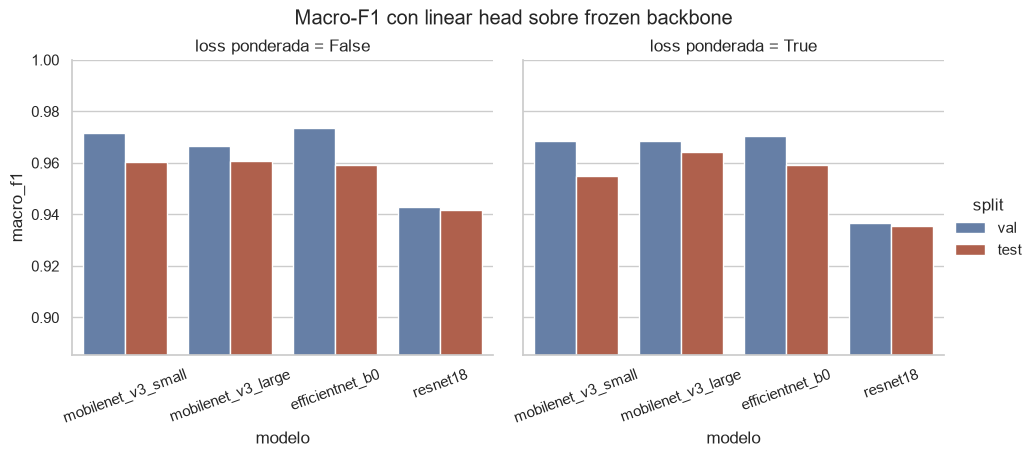

Mejor por macro-F1 en val: efficientnet_b0 (ponderada=False) -> val 0.9734 | test 0.9591


In [4]:
plot = res.melt(id_vars=["modelo", "loss ponderada"], value_vars=["val_macro_f1", "test_macro_f1"],
                var_name="split", value_name="macro_f1")
plot["split"] = plot["split"].str.replace("_macro_f1", "")
g = sns.catplot(data=plot, x="modelo", y="macro_f1", hue="split", col="loss ponderada",
                kind="bar", height=4, aspect=1.2, palette=["#5b7db1", "#c0563b"])
g.set_xticklabels(rotation=20); g.set(ylim=(max(0, plot.macro_f1.min() - 0.05), 1))
g.figure.suptitle("Macro-F1 con linear head sobre frozen backbone", y=1.03)
plt.show()

best_row = res.sort_values("val_macro_f1", ascending=False).iloc[0]
BEST_MODEL, BEST_W = best_row["modelo"], bool(best_row["loss ponderada"])
print(f"Mejor por macro-F1 en val: {BEST_MODEL} (ponderada={BEST_W}) -> val {best_row.val_macro_f1:.4f} | test {best_row.test_macro_f1:.4f}")


**Lectura sugerida:** comparar primero macro-F1 de validación para seleccionar la configuración y luego observar test. La ponderación de clases no necesariamente mejora macro-F1; su efecto debe evaluarse con las métricas por clase. También conviene considerar el costo del backbone: si dos modelos rinden de forma muy similar, el más liviano puede ser preferible cuando importan latencia o recursos.


## 4. Análisis por clase del mejor modelo

Precision, recall y F1 por clase (sobre **test**). El accuracy global esconde qué enfermedades cuestan más.

In [5]:
pred = preds[(BEST_MODEL, BEST_W)]
yt, yp = y[idx["test"]], pred[idx["test"]]
short = [c.replace("__", "_").replace("_", " ") for c in classes]
rep = pd.DataFrame(classification_report(yt, yp, target_names=short, output_dict=True, zero_division=0)).T
rep.loc[short].sort_values("f1-score").round(3)

,precision,recall,f1-score,support
Potato healthy,0.864,0.905,0.884,21.0
Tomato Early blight,0.912,0.874,0.893,143.0
Tomato Target Spot,0.907,0.920,0.914,201.0
Tomato Leaf Mold,0.947,0.919,0.933,136.0
Tomato Spider mites Two spotted spider mite,0.954,0.962,0.958,239.0
Potato Late blight,0.965,0.958,0.961,143.0
Tomato Septoria leaf spot,0.972,0.960,0.966,253.0
Tomato Late blight,0.971,0.971,0.971,273.0
Tomato healthy,0.978,0.978,0.978,228.0
Tomato Tomato mosaic virus,0.964,1.000,0.981,53.0


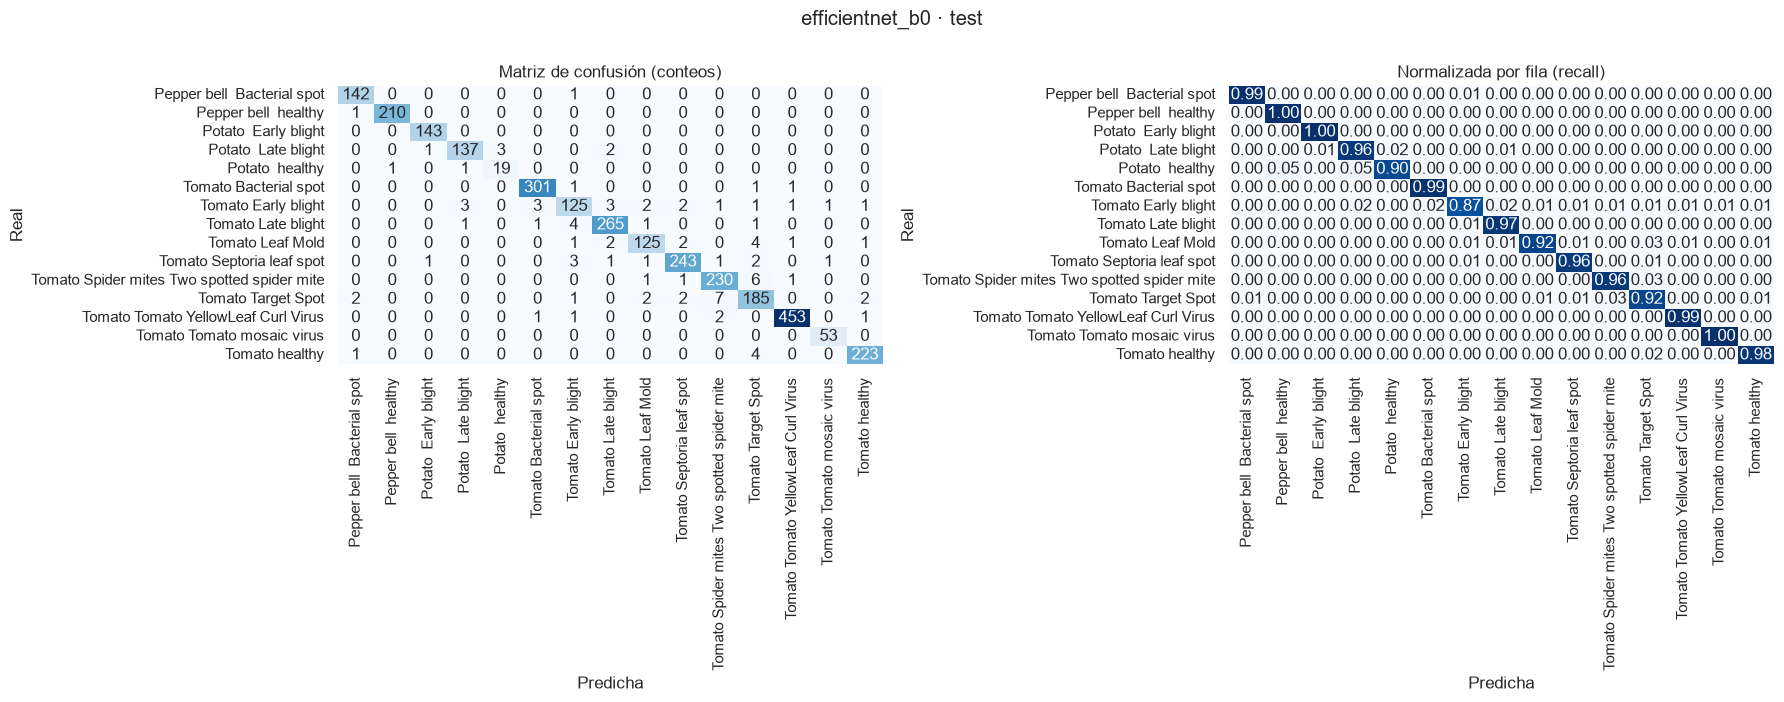

,real,predicha,errores
0,Tomato Target Spot,Tomato Spider mites Two spotted spider mite,7
1,Tomato Spider mites Two spotted spider mite,Tomato Target Spot,6
2,Tomato Late blight,Tomato Early blight,4
3,Tomato Leaf Mold,Tomato Target Spot,4
4,Tomato healthy,Tomato Target Spot,4
5,Potato Late blight,Potato healthy,3
6,Tomato Early blight,Potato Late blight,3
7,Tomato Early blight,Tomato Bacterial spot,3


In [6]:
cm = confusion_matrix(yt, yp)
cmn = cm / cm.sum(1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=short, yticklabels=short, ax=axes[0], cbar=False)
axes[0].set_title("Matriz de confusión (conteos)")
sns.heatmap(cmn, annot=True, fmt=".2f", cmap="Blues", xticklabels=short, yticklabels=short, ax=axes[1], cbar=False)
axes[1].set_title("Normalizada por fila (recall)")
for ax in axes:
    ax.set_xlabel("Predicha"); ax.set_ylabel("Real"); ax.tick_params(axis="x", rotation=90)
plt.suptitle(f"{BEST_MODEL} · test", y=1.0); plt.tight_layout(); plt.show()

pairs = [(short[i], short[j], int(cm[i, j])) for i in range(len(short)) for j in range(len(short)) if i != j and cm[i, j] > 0]
top = pd.DataFrame(sorted(pairs, key=lambda t: -t[2])[:8], columns=["real", "predicha", "errores"])
top


El análisis por clase permite identificar si los errores se concentran entre enfermedades visualmente parecidas de una misma especie. En la corrida previa, las confusiones más frecuentes aparecieron, por ejemplo, entre *Tomato Target Spot* y *Spider mites*, y entre distintas enfermedades de tomate; estas observaciones deben confirmarse con la ejecución actual.


## 5. Espacio de embeddings (PCA)

Proyectamos los embeddings del mejor modelo a 2D para ver qué clases están bien separadas antes de entrenar nada.

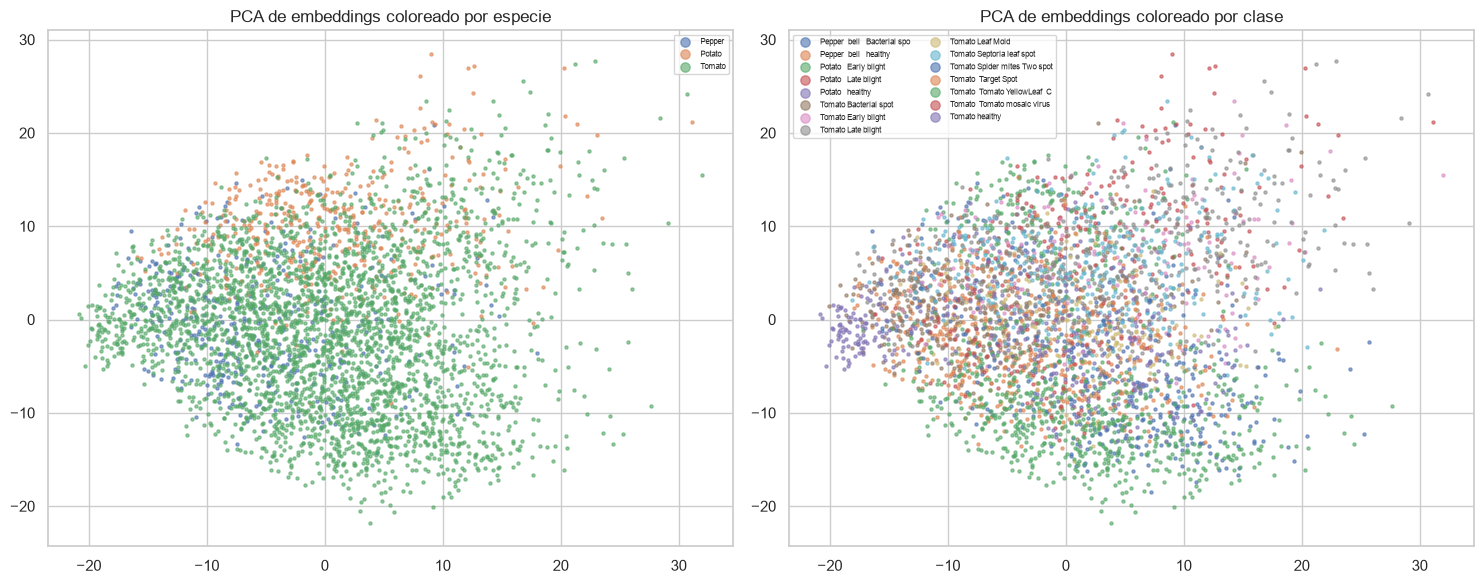

In [7]:
X = feats[BEST_MODEL]
sub = np.random.RandomState(SEED).choice(len(X), 4000, replace=False)
P = PCA(2, random_state=SEED).fit_transform((X[sub] - X[idx["train"]].mean(0)) / (X[idx["train"]].std(0) + 1e-6))
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, col, title in zip(axes, ["plant", "label"], ["Especie", "Clase"]):
    labs = df[col].values[sub]
    for l in sorted(set(labs)):
        m = labs == l
        ax.scatter(P[m, 0], P[m, 1], s=5, alpha=0.6, label=l.replace("_", " ")[:28])
    ax.set_title(f"PCA de embeddings coloreado por {title.lower()}"); ax.legend(markerscale=3, fontsize=6, ncol=1 if col == "plant" else 2)
plt.tight_layout(); plt.show()


## 6. Resumen y próximos pasos

- La tabla completa se guarda en `results/linear_probe.csv`.
- Este experimento funciona como **baseline con backbone congelado**.
- La selección de arquitectura se hace con macro-F1 de validación; test se reserva para el reporte.
- La extracción de embeddings y el linear probe usan CUDA automáticamente cuando está disponible.

**Notebook 03:** hacer fine-tuning parcial de MobileNetV3-Small y EfficientNet-B0, comparando cada arquitectura con y sin data augmentation bajo el mismo split.
